# 03c — Final Evaluation on Test Set (Week 3 Wrap-up)

**Champion model from 03b (dev-tuned):**
- LogisticRegression, `class_weight='balanced'`, `C=5`, `penalty='l2'`, `solver='lbfgs'`, `max_iter=2000`
- Features: TF-IDF word (1,2) ⊕ TF-IDF char (3,5), combined via `hstack`
- Dev F1_macro = **0.6392**

⚠ **This notebook touches `test.csv` for the FIRST and ONLY time in Week 3.**
No further hyper-parameter changes after this. Pure held-out evaluation.

## Setup & imports

In [1]:
import sys, time, json, joblib, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from scipy.sparse import hstack, save_npz
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

from configs.config import PATHS, COLUMNS, LABEL_MAP
from src.evaluate import evaluate_model, plot_confusion_matrix, save_predictions

print('ROOT:', ROOT)
print('LABEL_MAP:', LABEL_MAP)

ROOT: d:\Graduation Project
LABEL_MAP: {0: 'CLEAN', 1: 'OFFENSIVE', 2: 'HATE'}


## Part A — Test set evaluation (run-once)

### A.1  Load artefacts & build combined feature matrices

In [2]:
# Load vectorizers
word_vec = joblib.load(ROOT / 'models' / 'vectorizers' / 'tfidf_unibi.pkl')
char_vec = joblib.load(ROOT / 'models' / 'vectorizers' / 'tfidf_char.pkl')
print(f'Word vec n_features: {len(word_vec.get_feature_names_out()):,}')
print(f'Char vec n_features: {len(char_vec.get_feature_names_out()):,}')

# Load labels
y_train = np.load(ROOT / 'data' / 'processed' / 'y_train.npy')
y_dev   = np.load(ROOT / 'data' / 'processed' / 'y_dev.npy')
y_test  = np.load(ROOT / 'data' / 'processed' / 'y_test.npy')

# Load cleaned texts
train_df = pd.read_csv(ROOT / 'data' / 'processed' / 'train_cleaned.csv')
dev_df   = pd.read_csv(ROOT / 'data' / 'processed' / 'dev_cleaned.csv')
test_df  = pd.read_csv(ROOT / 'data' / 'processed' / 'test_cleaned.csv')
for df in (train_df, dev_df, test_df):
    df['cleaned'] = df['cleaned'].fillna('').astype(str)

# Word features (pre-saved)
X_train_w = sp.load_npz(ROOT / 'data' / 'processed' / 'X_train_tfidf_unibi.npz')
X_dev_w   = sp.load_npz(ROOT / 'data' / 'processed' / 'X_dev_tfidf_unibi.npz')
X_test_w  = sp.load_npz(ROOT / 'data' / 'processed' / 'X_test_tfidf_unibi.npz')

# Char features — load if present, else transform on the fly
char_train_path = ROOT / 'data' / 'processed' / 'X_train_char.npz'
char_dev_path   = ROOT / 'data' / 'processed' / 'X_dev_char.npz'
char_test_path  = ROOT / 'data' / 'processed' / 'X_test_char.npz'

X_train_c = sp.load_npz(char_train_path) if char_train_path.exists() else char_vec.transform(train_df['cleaned'])
X_dev_c   = sp.load_npz(char_dev_path)   if char_dev_path.exists()   else char_vec.transform(dev_df['cleaned'])

if char_test_path.exists():
    X_test_c = sp.load_npz(char_test_path)
else:
    X_test_c = char_vec.transform(test_df['cleaned'])
    save_npz(char_test_path, X_test_c)
    print(f'✓ Generated and saved {char_test_path.name}')

# hstack into combined features
X_train = hstack([X_train_w, X_train_c]).tocsr()
X_dev   = hstack([X_dev_w,   X_dev_c]).tocsr()
X_test  = hstack([X_test_w,  X_test_c]).tocsr()

print(f'X_train: {X_train.shape}   X_dev: {X_dev.shape}   X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}   y_dev: {y_dev.shape}   y_test: {y_test.shape}')

Word vec n_features: 10,000
Char vec n_features: 15,000
✓ Generated and saved X_test_char.npz
X_train: (24048, 25000)   X_dev: (2672, 25000)   X_test: (6680, 25000)
y_train: (24048,)   y_dev: (2672,)   y_test: (6680,)


### A.2  Refit champion (LR, C=5, balanced) on combined features & save

In [3]:
champion_path = ROOT / 'models' / 'baselines' / 'LR_champion.pkl'

t0 = time.perf_counter()
champion = LogisticRegression(
    C=5,
    class_weight='balanced',
    penalty='l2',
    solver='lbfgs',
    max_iter=2000,
    random_state=42,
    n_jobs=-1,
)
champion.fit(X_train, y_train)
train_time = time.perf_counter() - t0

# Sanity-check dev F1_macro matches 03b (~0.6392 ± noise)
y_dev_pred = champion.predict(X_dev)
dev_f1 = f1_score(y_dev, y_dev_pred, average='macro')
print(f'Train time: {train_time:.1f}s')
print(f'Dev F1_macro (refit): {dev_f1:.4f}    (target from 03b ≈ 0.6392)')

joblib.dump(champion, champion_path)
print(f'✓ Saved {champion_path.relative_to(ROOT)}  ({champion_path.stat().st_size/1024:.1f} KB)')

Train time: 2.2s
Dev F1_macro (refit): 0.6392    (target from 03b ≈ 0.6392)
✓ Saved models\baselines\LR_champion.pkl  (586.8 KB)


### A.3  Predict on test set (RUN-ONCE) & full evaluation

In [4]:
# Inference on test set — single forward pass, no further tuning
t0 = time.perf_counter()
y_test_pred  = champion.predict(X_test)
y_test_proba = champion.predict_proba(X_test)
test_inference_time = time.perf_counter() - t0

test_metrics = evaluate_model(
    y_true=y_test,
    y_pred=y_test_pred,
    model_name='LR_champion (word+char, C=5, balanced)',
    train_time=train_time,
    inference_time=test_inference_time,
)

print(test_metrics['classification_report'])
print(f'Inference time on test ({len(y_test):,} samples): {test_inference_time:.2f}s')

              precision    recall  f1-score   support

       CLEAN       0.94      0.89      0.91      5548
   OFFENSIVE       0.36      0.45      0.40       444
        HATE       0.49      0.60      0.54       688

    accuracy                           0.83      6680
   macro avg       0.60      0.65      0.62      6680
weighted avg       0.85      0.83      0.84      6680

Inference time on test (6,680 samples): 0.01s


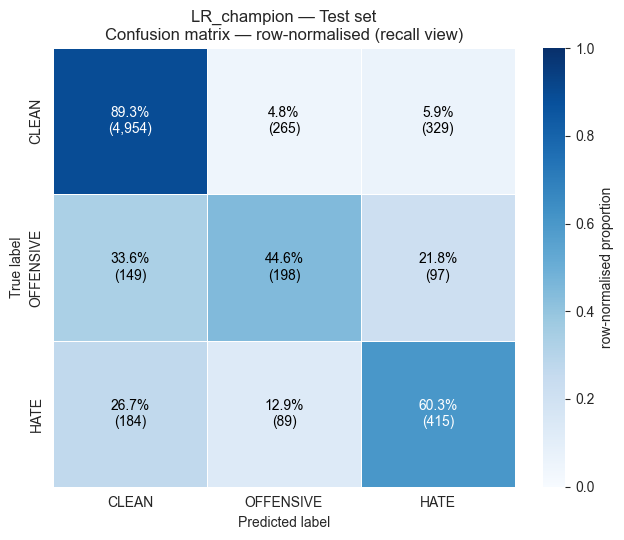

In [5]:
# Confusion matrix → results/figures/12_test_confusion_matrix.png
fig = plot_confusion_matrix(
    y_test, y_test_pred,
    model_name='LR_champion — Test set',
    save_path=ROOT / 'results' / 'figures' / '12_test_confusion_matrix.png',
    normalize=True,
)
plt.show()

In [6]:
# Save per-sample predictions → results/test_predictions.csv (Week-5 error analysis)
pred_df = save_predictions(
    texts   = test_df[COLUMNS['text']].tolist(),
    y_true  = y_test,
    y_pred  = y_test_pred,
    y_proba = y_test_proba,
    save_path = ROOT / 'results' / 'test_predictions.csv',
)
pred_df.head()

Saved 6,680 predictions → d:\Graduation Project\results\test_predictions.csv


,text,true_label,true_label_name,predicted_label,predicted_label_name,correct,confidence,proba_clean,proba_offensive,proba_hate
0,Đừng cố biện minh =)))) choi lon,0,CLEAN,2,HATE,False,0.5441,0.2066,0.2493,0.5441
1,Haizz. Nthe này thì dân khổ quá,1,OFFENSIVE,1,OFFENSIVE,True,0.5470,0.4367,0.5470,0.0163
2,the nay ma chi phat gay roi trat tu cong cong ...,0,CLEAN,0,CLEAN,True,0.7590,0.7590,0.0325,0.2085
3,Mua cho em hộp bcs mĩ sài cho oai :)),0,CLEAN,0,CLEAN,True,0.9443,0.9443,0.0470,0.0087
4,coin card :3,1,OFFENSIVE,0,CLEAN,False,0.9578,0.9578,0.0291,0.0130


### A.4  Dev vs Test comparison (generalisation check)

In [7]:
# Evaluate on dev with the same refit champion (so the comparison is apples-to-apples)
dev_metrics = evaluate_model(
    y_true=y_dev,
    y_pred=champion.predict(X_dev),
    model_name='LR_champion — Dev',
)

rows = []
for key in ['f1_macro', 'f1_clean', 'f1_offensive', 'f1_hate', 'accuracy',
            'precision_macro', 'recall_macro', 'f1_weighted']:
    dev_v  = dev_metrics[key]
    test_v = test_metrics[key]
    rows.append({
        'Metric': key,
        'Dev':   round(dev_v, 4),
        'Test':  round(test_v, 4),
        'Δ (Test-Dev)': round(test_v - dev_v, 4),
        'Δ %': f'{(test_v-dev_v)/dev_v*100:+.2f}%' if dev_v else '—',
    })

dev_vs_test = pd.DataFrame(rows)
print(dev_vs_test.to_string(index=False))

drop_pct = (dev_metrics['f1_macro'] - test_metrics['f1_macro']) / dev_metrics['f1_macro'] * 100
print()
if drop_pct > 5:
    print(f'⚠ Test F1_macro drop = {drop_pct:.2f}% > 5% → potential over-fitting.')
elif abs(drop_pct) < 2:
    print(f'✓ |Δ| = {abs(drop_pct):.2f}% < 2% → model generalises well.')
else:
    print(f'~ Test F1_macro drop = {drop_pct:.2f}% (2-5%) → mild gap, acceptable.')

         Metric    Dev   Test  Δ (Test-Dev)    Δ %
       f1_macro 0.6392 0.6183       -0.0209 -3.27%
       f1_clean 0.9208 0.9144       -0.0064 -0.69%
   f1_offensive 0.4365 0.3976       -0.0389 -8.92%
        f1_hate 0.5603 0.5428       -0.0174 -3.11%
       accuracy 0.8387 0.8334       -0.0053 -0.63%
precision_macro 0.6187 0.5964       -0.0223 -3.61%
   recall_macro 0.6664 0.6474       -0.0191 -2.86%
    f1_weighted 0.8460 0.8418       -0.0041 -0.49%

~ Test F1_macro drop = 3.27% (2-5%) → mild gap, acceptable.


## Part B — Production checklist & end-to-end predictor

### B.1  Verify champion artefacts

In [8]:
required_artefacts = {
    'Champion model':    ROOT / 'models' / 'baselines' / 'LR_champion.pkl',
    'Word vectorizer':   ROOT / 'models' / 'vectorizers' / 'tfidf_unibi.pkl',
    'Char vectorizer':   ROOT / 'models' / 'vectorizers' / 'tfidf_char.pkl',
    'Cleaner module':    ROOT / 'src' / 'preprocess.py',
    'Predictor module':  ROOT / 'src' / 'predict.py',
}
for name, path in required_artefacts.items():
    ok = path.exists()
    size_kb = path.stat().st_size / 1024 if ok else 0
    flag = '✅' if ok else '❌'
    print(f'  {flag}  {name:18s} → {path.relative_to(ROOT)}   ({size_kb:,.1f} KB)')

  ✅  Champion model     → models\baselines\LR_champion.pkl   (586.8 KB)
  ✅  Word vectorizer    → models\vectorizers\tfidf_unibi.pkl   (379.2 KB)
  ✅  Char vectorizer    → models\vectorizers\tfidf_char.pkl   (516.7 KB)
  ✅  Cleaner module     → src\preprocess.py   (10.9 KB)
  ✅  Predictor module   → src\predict.py   (3.3 KB)


### B.2  Smoke-test `ToxicCommentPredictor` on 5 sentences

In [9]:
# Force re-import in case the module was edited mid-session
import importlib
import src.predict
importlib.reload(src.predict)
from src.predict import ToxicCommentPredictor

clf = ToxicCommentPredictor()
test_sentences = [
    'xin chào mọi người',
    'đm thằng này ngu vl',
    'bài viết hay quá',
    'bọn nó toàn đồ rác rưởi',
    'ko hiểu sao thằng đó cứ nói linh tinh',
]

results = []
for s in test_sentences:
    out = clf.predict(s)
    results.append({
        'text': s,
        'predicted': out['label'],
        'confidence': round(out['confidence'], 4),
        'P(CLEAN)': round(out['probabilities']['CLEAN'], 3),
        'P(OFFENSIVE)': round(out['probabilities']['OFFENSIVE'], 3),
        'P(HATE)': round(out['probabilities']['HATE'], 3),
    })
pd.DataFrame(results)

,text,predicted,confidence,P(CLEAN),P(OFFENSIVE),P(HATE)
0,xin chào mọi người,CLEAN,0.9978,0.998,0.002,0.000
1,đm thằng này ngu vl,OFFENSIVE,0.7676,0.000,0.768,0.232
2,bài viết hay quá,CLEAN,0.9874,0.987,0.011,0.002
3,bọn nó toàn đồ rác rưởi,HATE,0.9075,0.044,0.049,0.907
4,ko hiểu sao thằng đó cứ nói linh tinh,CLEAN,0.5577,0.558,0.061,0.381


## Part C — Week-3 wrap-up artefacts

### C.1  Final comparison table (baseline → tuned → +char → test)

In [10]:
# Pull dev-side numbers from 03b summary; add fresh test row
tuning_json = ROOT / 'results' / 'week3_tuning_summary.json'
tuning = json.loads(tuning_json.read_text()) if tuning_json.exists() else {'dev_metrics': {}}
dm = tuning.get('dev_metrics', {})

def _row(name, metrics, split):
    return {
        'Stage': name,
        'Split': split,
        'F1_macro':    round(metrics['f1_macro'], 4),
        'F1_CLEAN':    round(metrics['f1_clean'], 4),
        'F1_OFFENSIVE':round(metrics['f1_offensive'], 4),
        'F1_HATE':     round(metrics['f1_hate'], 4),
        'Accuracy':    round(metrics['accuracy'], 4),
    }

summary_rows = []
if 'LR_baseline' in dm:
    summary_rows.append(_row('1. Baseline (LR_TFIDF_Balanced)', dm['LR_baseline'], 'dev'))
if 'LR_tuned_word' in dm:
    summary_rows.append(_row('2. Tuned (LR word, C=5 balanced)', dm['LR_tuned_word'], 'dev'))
if 'LR_tuned_char' in dm:
    summary_rows.append(_row('3. +Char n-grams (word ⊕ char)', dm['LR_tuned_char'], 'dev'))
if 'LR_char_thresh' in dm:
    summary_rows.append(_row('4. +Threshold (off=1.0, hate=1.0)', dm['LR_char_thresh'], 'dev'))
summary_rows.append(_row('5. Champion (refit) — TEST', test_metrics, 'test'))

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(ROOT / 'results' / 'week3_summary_table.csv', index=False)
print('✓ Saved results/week3_summary_table.csv')
summary_df

✓ Saved results/week3_summary_table.csv


,Stage,Split,F1_macro,F1_CLEAN,F1_OFFENSIVE,F1_HATE,Accuracy
0,1. Baseline (LR_TFIDF_Balanced),dev,0.6015,0.8894,0.3985,0.5166,0.7927
1,"2. Tuned (LR word, C=5 balanced)",dev,0.6024,0.8950,0.4000,0.5121,0.8009
2,3. +Char n-grams (word ⊕ char),dev,0.6392,0.9208,0.4365,0.5603,0.8387
3,"4. +Threshold (off=1.0, hate=1.0)",dev,0.6392,0.9208,0.4365,0.5603,0.8387
4,5. Champion (refit) — TEST,test,0.6183,0.9144,0.3976,0.5428,0.8334


### C.2  Per-class F1 on test (figure 13)

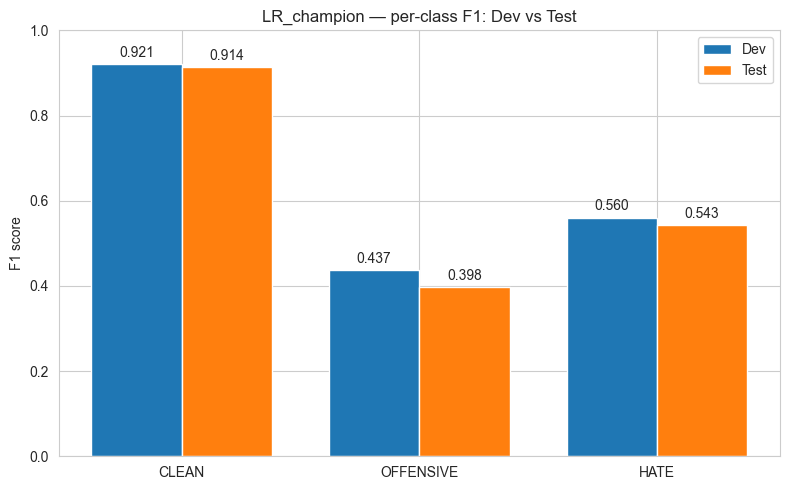

✓ Saved results\figures\13_test_per_class_f1.png


In [11]:
classes = ['CLEAN', 'OFFENSIVE', 'HATE']
f1_dev  = [dev_metrics['f1_clean'],  dev_metrics['f1_offensive'],  dev_metrics['f1_hate']]
f1_test = [test_metrics['f1_clean'], test_metrics['f1_offensive'], test_metrics['f1_hate']]

x = np.arange(len(classes))
w = 0.38
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, f1_dev,  w, label='Dev',  color='#1f77b4')
b2 = ax.bar(x + w/2, f1_test, w, label='Test', color='#ff7f0e')

for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}',
                ha='center', va='bottom', fontsize=10)

ax.set_xticks(x); ax.set_xticklabels(classes)
ax.set_ylabel('F1 score'); ax.set_ylim(0, 1.0)
ax.set_title('LR_champion — per-class F1: Dev vs Test')
ax.legend()
plt.tight_layout()
fig_path = ROOT / 'results' / 'figures' / '13_test_per_class_f1.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved {fig_path.relative_to(ROOT)}')

### C.3  Persist `results/week3_final_metrics.json`

In [14]:
def _serialisable(d):
    out = {}
    for k, v in d.items():
        if hasattr(v, 'tolist'):
            out[k] = v.tolist()
        elif isinstance(v, (np.floating, np.integer)):
            out[k] = float(v) if isinstance(v, np.floating) else int(v)
        else:
            out[k] = v
    return out

final_metrics = {
    'champion': {
        'algorithm': 'LogisticRegression',
        'features': 'TF-IDF word (1,2) ⊕ TF-IDF char (3,5), hstack',
        'best_params': {
            'C': 5,
            'class_weight': 'balanced',
            'penalty': 'l2',
            'solver': 'lbfgs',
            'max_iter': 2000,
            'random_state': 42,
        },
        'n_features_total': int(X_train.shape[1]),
    },
    'dev_metrics':  _serialisable(dev_metrics),
    'test_metrics': _serialisable(test_metrics),
    'dev_vs_test':  dev_vs_test.to_dict(orient='records'),
    'generalisation_gap': {
        'f1_macro_drop_pct': float(drop_pct),
        'verdict': ('over-fitting' if drop_pct > 5
                    else 'mild gap' if drop_pct > 2
                    else 'generalises well'),
    },
}

out_path = ROOT / 'results' / 'week3_final_metrics.json'
out_path.write_text(json.dumps(final_metrics, ensure_ascii=False, indent=2), encoding='utf-8')
print(f'✓ Saved {out_path.relative_to(ROOT)}')

✓ Saved results\week3_final_metrics.json


## ✅ Week 3 complete

- Champion model saved to `models/baselines/LR_champion.pkl`.
- End-to-end predictor in `src/predict.py` (text → label + probabilities).
- Test set has been touched **once** — no further tuning permitted in Week 3.
- See `reports/week3_final_summary.md` for the narrative summary.
- **Next:** Week 4 → BiLSTM + FastText (`04_deep_learning.ipynb`) and Week 5 → PhoBERT (`05_phobert.ipynb`). Target: F1_macro ≥ 0.70.